In [15]:
# Robin Torjussen Egede
# Streamlit App: https://ind320-hush.streamlit.app
# IND320 Repo: https://github.com/Kunii/IND320-hush/

In [16]:
from src.utils.dataloader import ReservoirData
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

In [17]:
rd = ReservoirData()  # Create an instance of ReservoirData
res_df = rd.load_csv() # Loads a lightly processed DF

res_df.head() # Display the first few rows of the DataFrame - Ensure it looks correct

,date,area_type,area_number,iso_year,iso_week,water_level,twh_cap,twh_fill,next_publication_date,water_level_prev_week,water_level_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,1-01-01 00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,1-01-01 00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,1-01-01 00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,1-01-01 00:00:00,0.311122,-0.010301


In [18]:
data = res_df.copy()[["date", "water_level", "water_level_prev_week", "water_level_change", "twh_cap", "twh_fill"]] # As to not modify the original DF
first_year = data[data["date"].dt.year == data["date"].dt.year.min()] # Get the first year in the dataset
first_month = first_year[first_year["date"].dt.month == first_year["date"].dt.month.min()] # Get the first month of the first year

print(f"Unique years (should be 1995): {first_year["date"].dt.year.unique()}") # Sanity check - Get the unique years in the first year dataframe
print(f"Unique months (should be 1): {first_month["date"].dt.month.unique()}") # Sanity check - Get the unique months in the first month dataframe

Unique years (should be 1995): [1995]
Unique months (should be 1): [1]


In [19]:
value_columns = first_month.select_dtypes(include="number").columns # Omit columns with non-numeric data

filtered_df = pd.DataFrame(
    {
        "Column Name": value_columns, # Column of original column names
        "First Month Values": [ # Values as a list
            first_month[column].tolist() for column in value_columns
        ],
    }
)

display(filtered_df)

,Column Name,First Month Values
0,water_level,"[0.5506037, 0.6214672, 0.5222617, 0.5588641, 0..."
1,water_level_prev_week,"[0.58309984, 0.7348877, 0.54069, 0.80134785, 0..."
2,water_level_change,"[-0.032496154, -0.113420546, -0.018428326, -0...."
3,twh_cap,"[6.0032635, 6.0032635, 21.079208, 21.079208, 6..."
4,twh_fill,"[3.3054192, 3.7308314, 11.008863, 11.780413, 3..."


In [20]:
# Rescale all numeric cols to relative scale
for column in value_columns:
    if (first_month[column].max() > 1.0):
        first_month[column] = first_month[column] / first_month[column].max() # Rescale to relative scale

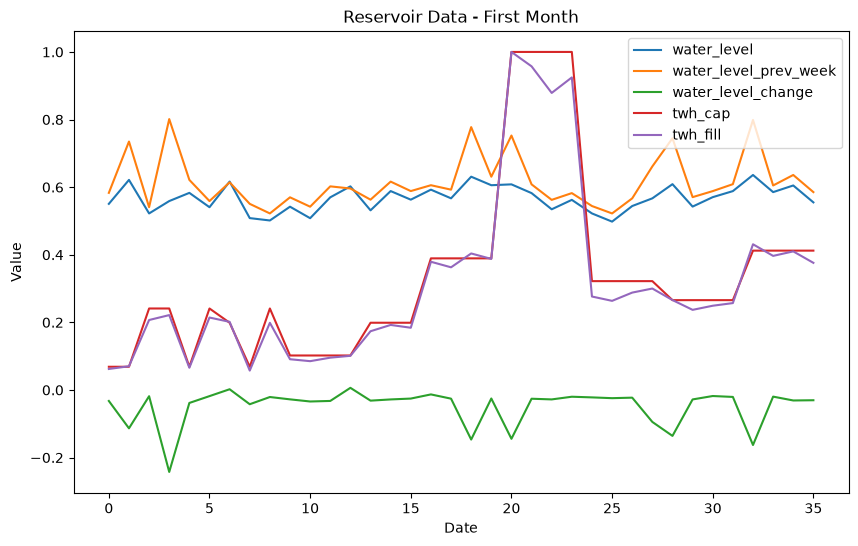

In [21]:
plt.figure(figsize=(10, 6)) # type: ignore
for column in value_columns:
    plt.plot(range(len(first_month)), first_month[column], label=column) # Plot each column against the date # type: ignore

plt.xlabel("Date") # type: ignore
plt.ylabel("Value") # type: ignore
plt.title("Reservoir Data - First Month") # type: ignore
plt.legend() # type: ignore
plt.show() # type: ignore